# Simulação Computacional: Convolução Discreta

A convolução é a espinha dorsal do processamento de sinais LTI. Se conhecermos a resposta de um sistema a um impulso unitário ($h[n]$), podemos determinar a saída ($y[n]$) para qualquer entrada arbitrária ($x[n]$).

Neste experimento, aplicaremos o nosso pulso transitório de tensão a um sistema modelado com uma resposta ao impulso de decaimento exponencial (representando, por exemplo, a característica de descarga de um circuito RC).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

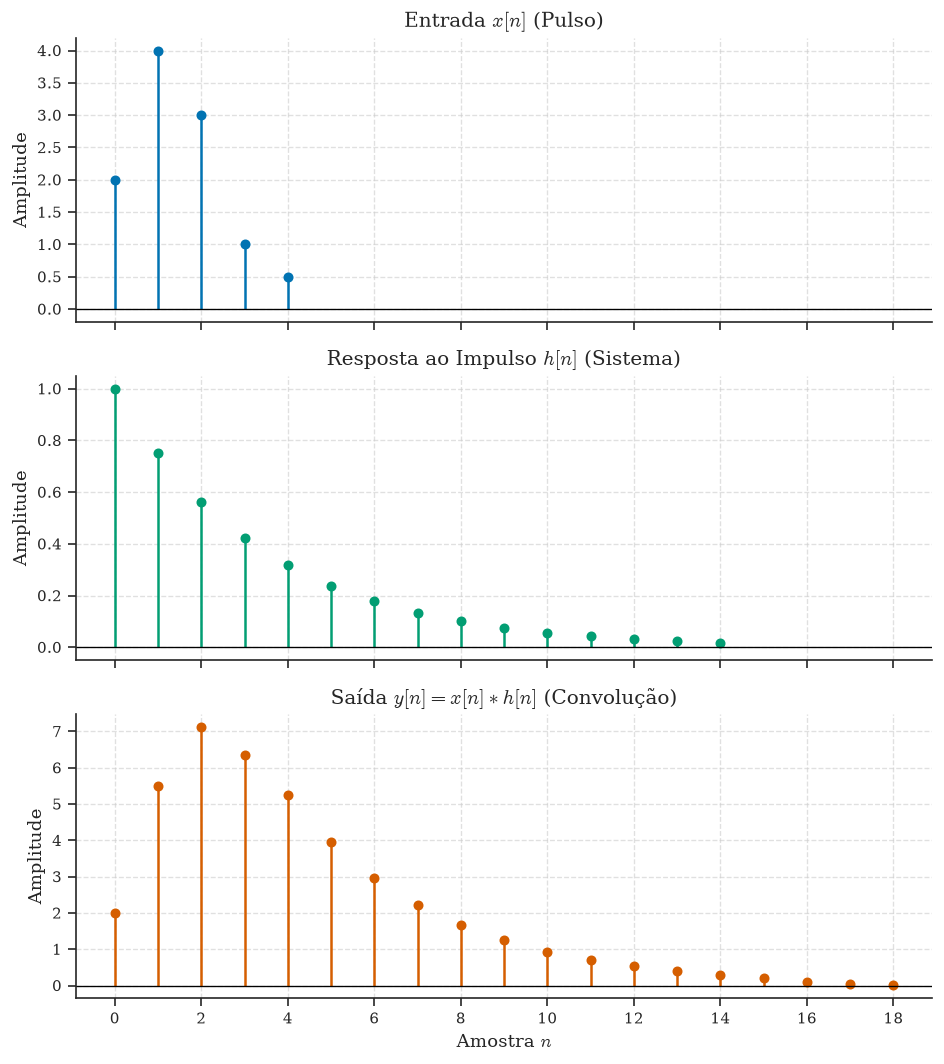

In [2]:
# 1. Sinal de Entrada x[n]: Pulso transitório (suporte: n=0 até n=4)
nx = np.arange(0, 5)
x = np.array([2.0, 4.0, 3.0, 1.0, 0.5])

# 2. Resposta ao Impulso h[n]: Decaimento exponencial (suporte: n=0 até n=14)
nh = np.arange(0, 15)
h = (0.75)**nh  # Fator de decaimento a = 0.75

# 3. Operação de Convolução Discreta: y[n] = x[n] * h[n]
y = np.convolve(x, h, mode='full')

# O vetor de tempo resultante ny tem tamanho len(nx) + len(nh) - 1
ny = np.arange(nx[0] + nh[0], nx[-1] + nh[-1] + 1)

# 4. Configuração da Figura (Painel 3x1)
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
cores = sns.color_palette("colorblind")

sinais = [
    (axes[0], nx, x, r"Entrada $x[n]$ (Pulso)", cores[0]),
    (axes[1], nh, h, r"Resposta ao Impulso $h[n]$ (Sistema)", cores[2]),
    (axes[2], ny, y, r"Saída $y[n] = x[n] * h[n]$ (Convolução)", cores[3])
]

for ax, n_vec, seq, titulo, cor in sinais:
    markerline, stemlines, baseline = ax.stem(
        n_vec, seq, linefmt="-", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, color=cor, linewidth=1.5)
    plt.setp(markerline, color=cor, markersize=5)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_title(titulo)
    ax.set_ylabel("Amplitude")

axes[2].set_xlabel(r"Amostra $n$")
axes[2].set_xticks(np.arange(0, ny[-1] + 1, 2))

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_convolucao.png")
plt.show()

In [3]:
print("=== PROPRIEDADES DA CONVOLUÇÃO ===")
print(f"Tamanho de x[n] (L) : {len(x)} amostras")
print(f"Tamanho de h[n] (M) : {len(h)} amostras")
print(f"Tamanho esperado de y[n] : L + M - 1 = {len(x) + len(h) - 1}")
print(f"Tamanho medido de y[n]   : {len(y)}")
print("-" * 35)
print(f"Soma das amplitudes (x) : {np.sum(x):.2f}")
print(f"Soma das amplitudes (h) : {np.sum(h):.2f}")
print(f"Soma esperada (y)       : {np.sum(x) * np.sum(h):.2f}")
print(f"Soma medida (y)         : {np.sum(y):.2f}")

=== PROPRIEDADES DA CONVOLUÇÃO ===
Tamanho de x[n] (L) : 5 amostras
Tamanho de h[n] (M) : 15 amostras
Tamanho esperado de y[n] : L + M - 1 = 19
Tamanho medido de y[n]   : 19
-----------------------------------
Soma das amplitudes (x) : 10.50
Soma das amplitudes (h) : 3.95
Soma esperada (y)       : 41.44
Soma medida (y)         : 41.44
